# OT2 One Character Optimizer

This notebook is a visualization shell around the real Python modules. Edit `configs/one_character.example.json`, then run these cells.

In [5]:
import json
import sys
from pathlib import Path

# Make local package imports work whether the kernel starts in the repo root
# or inside the notebooks/ directory.
project_root = Path.cwd().resolve()
if not (project_root / 'ot2_optimizer').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from ot2_optimizer.data_loader import load_equipment
from ot2_optimizer.optimizer import optimize_character

config = json.loads((project_root / 'configs/one_character.example.json').read_text())
result = optimize_character(config, load_equipment(project_root))
result.to_jsonable()

{'character': 'Osvald',
 'level': 18,
 'class': 'Scholar',
 'selected_locations': ['New Delsta',
  'Canalbrine',
  'Beasting Village',
  'Ryu',
  'Flamechurch',
  'Oresrush',
  'Cropdale',
  'Cape Cold'],
 'total_cost': 24600,
 'current_stats': {'hp': 850,
  'sp': 95,
  'phys_atk': 64,
  'elem_atk': 156,
  'phys_def': 104,
  'elem_def': 137,
  'speed': 64,
  'accuracy': 78,
  'evasion': 62,
  'critical': 50},
 'recommended_stats': {'hp': 850,
  'sp': 125,
  'phys_atk': 111,
  'elem_atk': 250,
  'phys_def': 134,
  'elem_def': 177,
  'speed': 64,
  'accuracy': 78,
  'evasion': 63,
  'critical': 50},
 'recommendations': {'weapon': {'item': 'Oak Staff',
   'category': 'Staves',
   'score': 97.72,
   'price': 19000,
   'stat_delta': {'phys_atk': 47, 'elem_atk': 94, 'evasion': 31},
   'effect_points': {},
   'effect_tags': [],
   'availability': 'Store [New Delsta (*)], [Winterbloom]',
   'reasons': ['elem_atk +94 x 1 (priority) = +94.0',
    'evasion +31 x 0.12 (floor) = +3.7',
    'loadout

In [6]:
for slot, score in result.recommendations.items():
    print(slot, score.item.name, score.score)
    print('  delta:', score.stat_delta)
    print('  effects:', score.effect_points)
    print()

weapon Oak Staff 97.72
  delta: {'phys_atk': 47, 'elem_atk': 94, 'evasion': 31}
  effects: {}

shield Crested Greatshield 19.5
  delta: {'phys_def': 20, 'elem_def': 22, 'evasion': -30}
  effects: {}

headgear Silver Hairpiece 22.9
  delta: {'sp': 30, 'phys_def': 10, 'elem_def': 18}
  effects: {}

body_armor Fur Armor 0.0
  delta: {}
  effects: {}



In [7]:
stats = sorted(result.current_stats)
for stat in stats:
    current = result.current_stats[stat]
    recommended = result.recommended_stats[stat]
    print(f'{stat:10s} current={current:4d} recommended={recommended:4d} delta={recommended-current:+4d}')

accuracy   current=  78 recommended=  78 delta=  +0
critical   current=  50 recommended=  50 delta=  +0
elem_atk   current= 156 recommended= 250 delta= +94
elem_def   current= 137 recommended= 177 delta= +40
evasion    current=  62 recommended=  63 delta=  +1
hp         current= 850 recommended= 850 delta=  +0
phys_atk   current=  64 recommended= 111 delta= +47
phys_def   current= 104 recommended= 134 delta= +30
sp         current=  95 recommended= 125 delta= +30
speed      current=  64 recommended=  64 delta=  +0


Optional matplotlib chart if matplotlib is installed.

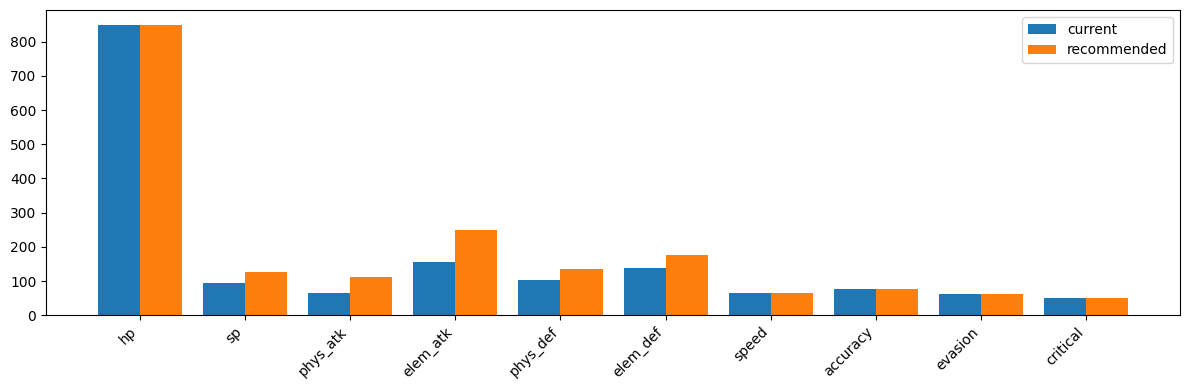

In [10]:
try:
    import matplotlib.pyplot as plt
    stats = list(result.current_stats)
    current = [result.current_stats[s] for s in stats]
    recommended = [result.recommended_stats[s] for s in stats]
    x = range(len(stats))
    plt.figure(figsize=(12, 4))
    plt.bar([i - 0.2 for i in x], current, width=0.4, label='current')
    plt.bar([i + 0.2 for i in x], recommended, width=0.4, label='recommended')
    plt.xticks(list(x), stats, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
except ImportError:
    print('matplotlib is not installed; use the generated HTML report instead.')